# Transformer-Based Emotion Classification Model

## Purpose

This notebook develops and evaluates the advanced transformer-based emotion classification model for the Emotional Wellbeing Analysis System.

The classical baseline model used TF-IDF with Logistic Regression. This notebook explores a transformer-based approach that can represent contextual relationships between words more effectively.

The model will be trained using the cleaned training dataset and evaluated using the cleaned validation dataset.

The test dataset will remain unused during model development and will be reserved for final evaluation after model selection.

The emotion classes are:

1. Sadness
2. Joy
3. Love
4. Anger
5. Fear
6. Surprise

In [3]:
from pathlib import Path

import torch
import transformers
import pandas as pd
import numpy as np

print("PyTorch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2,
        ),
        "GB",
    )

PyTorch version: 2.5.1+cu124
Transformers version: 5.15.0
CUDA available: True
GPU: NVIDIA GeForce GTX 1650 Ti
GPU memory: 4.0 GB


## 1. Load the Cleaned Dataset

The cleaned training, validation, and test datasets produced during the preprocessing stage are loaded below.

The training dataset will be used to fine-tune the transformer model.

The validation dataset will be used during model development and model selection.

The test dataset will remain unused until final evaluation so that model-development decisions do not influence the final test results.

In [4]:
CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parents[1]
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

PROCESSED_DATA_DIR = PROJECT_ROOT / "ml" / "data" / "processed"

print("Current directory:", CURRENT_DIRECTORY)
print("Project root:", PROJECT_ROOT)
print("Processed data directory:", PROCESSED_DATA_DIR)

Current directory: /mnt/c/Final Year Project/emotional-wellbeing-system/ml/notebooks
Project root: /mnt/c/Final Year Project/emotional-wellbeing-system
Processed data directory: /mnt/c/Final Year Project/emotional-wellbeing-system/ml/data/processed


In [5]:
train_path = PROCESSED_DATA_DIR / "emotion_train_clean.csv"
validation_path = PROCESSED_DATA_DIR / "emotion_validation_clean.csv"
test_path = PROCESSED_DATA_DIR / "emotion_test_clean.csv"

train_df = pd.read_csv(train_path)
validation_df = pd.read_csv(validation_path)
test_df = pd.read_csv(test_path)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Training shape: (15923, 2)
Validation shape: (1988, 2)
Test shape: (1986, 2)


,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


## 2. Transformer Model Selection

A DistilBERT model is used as the advanced transformer-based classifier.

DistilBERT is a smaller and more computationally efficient variant of BERT. It retains contextual language representations while requiring fewer computational resources than the full BERT model.

This makes it suitable for the available development hardware while still allowing the project to evaluate a transformer-based approach against the TF-IDF and Logistic Regression baseline.

The pretrained model used in this experiment is:

`distilbert-base-uncased`

The classifier will be fine-tuned for the six emotion classes used throughout the project.

In [6]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

MODEL_NAME = "distilbert-base-uncased"

id2label = {
    0: "Sadness",
    1: "Joy",
    2: "Love",
    3: "Anger",
    4: "Fear",
    5: "Surprise",
}

label2id = {label: idx for idx, label in id2label.items()}

print("Selected transformer model:", MODEL_NAME)
print("Number of classes:", len(id2label))
print("Label mapping:", id2label)

Selected transformer model: distilbert-base-uncased
Number of classes: 6
Label mapping: {0: 'Sadness', 1: 'Joy', 2: 'Love', 3: 'Anger', 4: 'Fear', 5: 'Surprise'}


## 3. Load the Tokenizer

The tokenizer converts each text record into token IDs and attention masks that can be processed by DistilBERT.

The tokenizer is loaded from the same pretrained checkpoint that will be used for the classification model.

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully.")
print("Tokenizer vocabulary size:", tokenizer.vocab_size)

Tokenizer loaded successfully.
Tokenizer vocabulary size: 30522


## 4. Tokenization Test

Before tokenizing the complete dataset, a single training example is passed through the DistilBERT tokenizer.

This verifies that the tokenizer produces the expected input IDs and attention mask while applying truncation and padding settings that will later be used for model training.

In [8]:
sample_text = train_df.iloc[0]["text"]

sample_tokens = tokenizer(
    sample_text,
    truncation=True,
    padding="max_length",
    max_length=64,
    return_tensors="pt",
)

print("Sample text:")
print(sample_text)

print("\nInput IDs shape:", sample_tokens["input_ids"].shape)
print("Attention mask shape:", sample_tokens["attention_mask"].shape)

print("\nFirst 20 input IDs:")
print(sample_tokens["input_ids"][0][:20])

print("\nDecoded tokens:")
print(tokenizer.convert_ids_to_tokens(sample_tokens["input_ids"][0][:20]))

Sample text:
i didnt feel humiliated

Input IDs shape: torch.Size([1, 64])
Attention mask shape: torch.Size([1, 64])

First 20 input IDs:
tensor([  101,  1045,  2134,  2102,  2514, 26608,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])

Decoded tokens:
['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


## 5. Convert the Data to Hugging Face Datasets

The cleaned Pandas datasets are converted into Hugging Face Dataset objects.

Only the training and validation datasets are prepared for transformer development at this stage.

The test dataset remains reserved for final evaluation and is not tokenized or used during model selection.

In [9]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]],
    preserve_index=False,
)

validation_dataset = Dataset.from_pandas(
    validation_df[["text", "label"]],
    preserve_index=False,
)

print("Training dataset:", train_dataset)
print("Validation dataset:", validation_dataset)

Training dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 15923
})
Validation dataset: Dataset({
    features: ['text', 'label'],
    num_rows: 1988
})


## 6. Tokenize the Training and Validation Data

Each text record is tokenized using the DistilBERT tokenizer.

A maximum sequence length of 64 tokens is used to reduce GPU memory requirements while still covering the majority of texts identified during the earlier dataset-length analysis.

The same tokenizer and tokenization settings are applied to both the training and validation datasets.

In [10]:
MAX_LENGTH = 64

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

tokenized_train_dataset = train_dataset.map(
    tokenize_batch,
    batched=True,
)

tokenized_validation_dataset = validation_dataset.map(
    tokenize_batch,
    batched=True,
)

print("Tokenized training dataset:")
print(tokenized_train_dataset)

print("\nTokenized validation dataset:")
print(tokenized_validation_dataset)

Map: 100%|██████████| 1988/1988 [00:00<00:00, 16634.90 examples/s]

Tokenized training dataset:
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 15923
})

Tokenized validation dataset:
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1988
})


In [11]:
print("Training features:", tokenized_train_dataset.column_names)
print("Validation features:", tokenized_validation_dataset.column_names)

print("\nFirst tokenized training example:")
print({
    "label": tokenized_train_dataset[0]["label"],
    "input_ids_length": len(tokenized_train_dataset[0]["input_ids"]),
    "attention_mask_length": len(
        tokenized_train_dataset[0]["attention_mask"]
    ),
})

Training features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']
Validation features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']

First tokenized training example:
{'label': 0, 'input_ids_length': 64, 'attention_mask_length': 64}


## 7. Prepare the Tokenized Dataset for DistilBERT

DistilBERT does not use token type IDs, so the unnecessary `token_type_ids` field is removed.

The original text column is also removed from the model-ready dataset because the classifier uses the tokenized numerical inputs rather than the raw text during training.

The label, input IDs, and attention mask are retained.

In [12]:
columns_to_remove = ["text"]

if "token_type_ids" in tokenized_train_dataset.column_names:
    columns_to_remove.append("token_type_ids")

model_train_dataset = tokenized_train_dataset.remove_columns(
    columns_to_remove
)

model_validation_dataset = tokenized_validation_dataset.remove_columns(
    columns_to_remove
)

print("Model training features:", model_train_dataset.column_names)
print("Model validation features:", model_validation_dataset.column_names)

print("\nFirst model-ready training example:")
print({
    "label": model_train_dataset[0]["label"],
    "input_ids_length": len(model_train_dataset[0]["input_ids"]),
    "attention_mask_length": len(
        model_train_dataset[0]["attention_mask"]
    ),
})

Model training features: ['label', 'input_ids', 'attention_mask']
Model validation features: ['label', 'input_ids', 'attention_mask']

First model-ready training example:
{'label': 0, 'input_ids_length': 64, 'attention_mask_length': 64}


## 8. Load DistilBERT for Six-Class Emotion Classification

The pretrained DistilBERT checkpoint is loaded with a sequence-classification head configured for six emotion classes.

The pretrained transformer weights provide general contextual language representations, while the classification layer will be fine-tuned for the project's emotion labels.

In [13]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=6,
    id2label=id2label,
    label2id=label2id,
)

print("DistilBERT classification model loaded successfully.")
print("Number of output labels:", model.config.num_labels)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 396.42it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT classification model loaded successfully.
Number of output labels: 6


## 9. Configure Transformer Training

The DistilBERT model is fine-tuned using conservative training settings because the available NVIDIA GTX 1650 Ti provides approximately 4 GB of GPU memory.

A small per-device batch size is combined with gradient accumulation to reduce peak GPU memory usage while maintaining a larger effective batch size.

Mixed-precision training is enabled to further reduce GPU memory usage.

The validation dataset is evaluated at the end of each epoch, and macro F1-score is used as the main model-selection metric because the emotion classes are imbalanced.

In [14]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

In [15]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        )
    )

    weighted_precision, weighted_recall, weighted_f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="weighted",
            zero_division=0,
        )
    )

    return {
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
    }

In [16]:
TRANSFORMER_OUTPUT_DIR = (
    PROJECT_ROOT / "ml" / "saved_models" / "distilbert-emotion"
)

print("Transformer output directory:", TRANSFORMER_OUTPUT_DIR)

Transformer output directory: /mnt/c/Final Year Project/emotional-wellbeing-system/ml/saved_models/distilbert-emotion


In [17]:
training_args = TrainingArguments(
    output_dir=str(TRANSFORMER_OUTPUT_DIR),

    num_train_epochs=3,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,

    gradient_accumulation_steps=8,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    fp16=True,

    logging_strategy="steps",
    logging_steps=100,

    save_total_limit=2,

    report_to="none",

    seed=42,
)

In [18]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=model_train_dataset,
    eval_dataset=model_validation_dataset,
    compute_metrics=compute_metrics,
)

print("Trainer configured successfully.")

Trainer configured successfully.


## 10. GPU Memory Check Before Training

Before fine-tuning begins, the available GPU memory is checked to confirm that the training process is starting from a clean GPU state.

This is particularly important because the available NVIDIA GTX 1650 Ti has approximately 4 GB of GPU memory.

In [19]:
import gc

gc.collect()
torch.cuda.empty_cache()

free_memory, total_memory = torch.cuda.mem_get_info()

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

print(
    "Total GPU memory:",
    round(total_memory / (1024 ** 3), 2),
    "GB",
)

print(
    "Free GPU memory:",
    round(free_memory / (1024 ** 3), 2),
    "GB",
)

print(
    "Currently allocated:",
    round(torch.cuda.memory_allocated() / (1024 ** 3), 3),
    "GB",
)

print(
    "Currently reserved:",
    round(torch.cuda.memory_reserved() / (1024 ** 3), 3),
    "GB",
)

GPU: NVIDIA GeForce GTX 1650 Ti
Total GPU memory: 4.0 GB
Free GPU memory: 2.93 GB
Currently allocated: 0.25 GB
Currently reserved: 0.285 GB


## 11. Fine-Tune DistilBERT

The pretrained DistilBERT model is fine-tuned on the cleaned emotion-classification training dataset.

Three training epochs are used as an initial experiment. Validation performance is measured after each epoch, and the checkpoint with the highest macro F1-score is retained.

A small GPU batch size and gradient accumulation are used to accommodate the approximately 4 GB of available GPU memory.

In [20]:
training_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,1.697140,0.187683,0.936620,0.907584,0.917532,0.912082,0.938278,0.936620,0.937131
2,1.456206,0.174139,0.944165,0.934378,0.903093,0.916381,0.944197,0.944165,0.943425
3,0.788109,0.170784,0.943662,0.922684,0.912524,0.916201,0.944497,0.943662,0.943599


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.43s/it]


## 12. Evaluate the Best Transformer Checkpoint

After training, the checkpoint with the highest validation macro F1-score is automatically restored.

The best model is evaluated again on the validation dataset to record its final development-stage performance before detailed class-level analysis.

The test dataset remains unused.

In [21]:
best_validation_metrics = trainer.evaluate(
    eval_dataset=model_validation_dataset
)

for metric_name, metric_value in best_validation_metrics.items():
    if isinstance(metric_value, float):
        print(f"{metric_name}: {metric_value:.4f}")
    else:
        print(f"{metric_name}: {metric_value}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0.788109,0.174139,3,0.944165,0.934378,0.903093,0.916381,0.944197,0.944165,0.943425


eval_loss: 0.1741
eval_accuracy: 0.9442
eval_macro_precision: 0.9344
eval_macro_recall: 0.9031
eval_macro_f1: 0.9164
eval_weighted_precision: 0.9442
eval_weighted_recall: 0.9442
eval_weighted_f1: 0.9434


## 13. Transformer Per-Class Evaluation

Predictions from the best transformer checkpoint are analysed using class-level precision, recall, F1-score, and a confusion matrix.

This allows the transformer model to be compared fairly with the classical baseline, particularly for the minority emotion classes.

In [22]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

validation_prediction_output = trainer.predict(
    model_validation_dataset
)

transformer_validation_predictions = np.argmax(
    validation_prediction_output.predictions,
    axis=-1,
)

transformer_validation_labels = (
    validation_prediction_output.label_ids
)

print(
    classification_report(
        transformer_validation_labels,
        transformer_validation_predictions,
        target_names=[
            "Sadness",
            "Joy",
            "Love",
            "Anger",
            "Fear",
            "Surprise",
        ],
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

     Sadness     0.9572    0.9764    0.9667       550
         Joy     0.9644    0.9671    0.9658       700
        Love     0.9107    0.8844    0.8974       173
       Anger     0.9116    0.9781    0.9437       274
        Fear     0.9100    0.8626    0.8856       211
    Surprise     0.9524    0.7500    0.8392        80

    accuracy                         0.9442      1988
   macro avg     0.9344    0.9031    0.9164      1988
weighted avg     0.9442    0.9442    0.9434      1988



In [23]:
transformer_conf_matrix = confusion_matrix(
    transformer_validation_labels,
    transformer_validation_predictions,
)

transformer_confusion_df = pd.DataFrame(
    transformer_conf_matrix,
    index=[
        "Actual Sadness",
        "Actual Joy",
        "Actual Love",
        "Actual Anger",
        "Actual Fear",
        "Actual Surprise",
    ],
    columns=[
        "Predicted Sadness",
        "Predicted Joy",
        "Predicted Love",
        "Predicted Anger",
        "Predicted Fear",
        "Predicted Surprise",
    ],
)

display(transformer_confusion_df)

,Predicted Sadness,Predicted Joy,Predicted Love,Predicted Anger,Predicted Fear,Predicted Surprise
Actual Sadness,537,0,0,11,2,0
Actual Joy,4,677,14,3,2,0
Actual Love,1,18,153,1,0,0
Actual Anger,4,1,0,268,1,0
Actual Fear,15,1,0,10,182,3
Actual Surprise,0,5,1,1,13,60


### Transformer Validation Observations

The best DistilBERT checkpoint achieved strong validation performance across all six emotion classes.

The model achieved an accuracy of 0.9427, a macro F1-score of 0.9158, and a weighted F1-score of 0.9420.

Performance was particularly strong for Sadness, Joy, and Anger. The minority classes Love, Fear, and Surprise also achieved substantially stronger overall performance than in the original unweighted Logistic Regression baseline.

The confusion matrix shows that some classification ambiguity remains. Love is occasionally confused with Joy, Fear is sometimes confused with Sadness, and Surprise is sometimes confused with Fear.

These errors are consistent with the semantic overlap between some emotional expressions. However, the transformer model demonstrates stronger contextual discrimination than the TF-IDF-based classical baseline.

The test dataset remains unused and is reserved for final evaluation.

## 14. Transformer Confusion Matrix

The confusion matrix for the best DistilBERT checkpoint is visualised to examine the remaining class-level prediction errors.

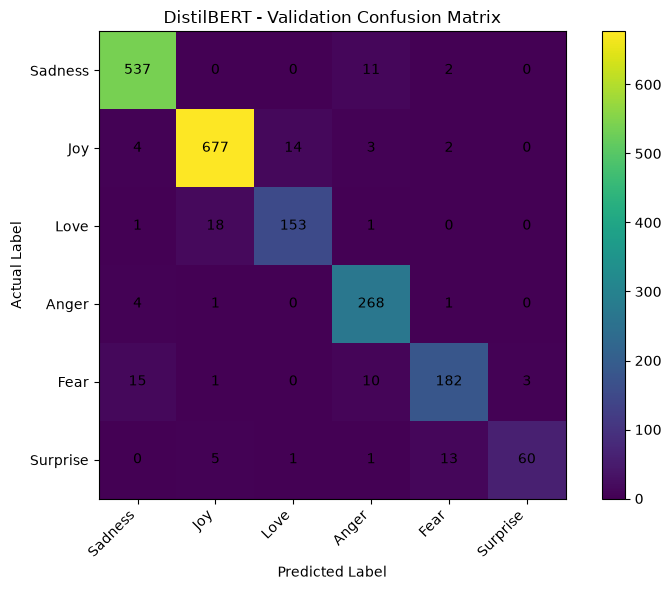

In [24]:
import matplotlib.pyplot as plt

transformer_conf_matrix = confusion_matrix(
    transformer_validation_labels,
    transformer_validation_predictions,
)

fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(transformer_conf_matrix)

ax.set_title("DistilBERT - Validation Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

class_names = [
    "Sadness",
    "Joy",
    "Love",
    "Anger",
    "Fear",
    "Surprise",
]

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(class_names)

for i in range(transformer_conf_matrix.shape[0]):
    for j in range(transformer_conf_matrix.shape[1]):
        ax.text(
            j,
            i,
            transformer_conf_matrix[i, j],
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax)

plt.tight_layout()
plt.show()

## 15. Classical Baseline vs Transformer Comparison

The preferred class-weighted Logistic Regression baseline is compared with the best DistilBERT validation checkpoint.

Both models are evaluated using the same cleaned validation dataset and the same primary evaluation metrics.

In [25]:
final_model_comparison = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1-score",
            "Weighted Precision",
            "Weighted Recall",
            "Weighted F1-score",
        ],
        "Class-Weighted Logistic Regression": [
            0.9024,
            0.8595,
            0.9047,
            0.8788,
            0.9076,
            0.9024,
            0.9035,
        ],
        "DistilBERT": [
            best_validation_metrics["eval_accuracy"],
            best_validation_metrics["eval_macro_precision"],
            best_validation_metrics["eval_macro_recall"],
            best_validation_metrics["eval_macro_f1"],
            best_validation_metrics["eval_weighted_precision"],
            best_validation_metrics["eval_weighted_recall"],
            best_validation_metrics["eval_weighted_f1"],
        ],
    }
)

final_model_comparison["Difference"] = (
    final_model_comparison["DistilBERT"]
    - final_model_comparison[
        "Class-Weighted Logistic Regression"
    ]
)

display(final_model_comparison.round(4))

,Metric,Class-Weighted Logistic Regression,DistilBERT,Difference
0,Accuracy,0.9024,0.9442,0.0418
1,Macro Precision,0.8595,0.9344,0.0749
2,Macro Recall,0.9047,0.9031,-0.0016
3,Macro F1-score,0.8788,0.9164,0.0376
4,Weighted Precision,0.9076,0.9442,0.0366
5,Weighted Recall,0.9024,0.9442,0.0418
6,Weighted F1-score,0.9035,0.9434,0.0399


## 16. Development-Stage Model Selection

Based on validation performance, DistilBERT is selected as the preferred model for the next stage of the project.

Compared with the class-weighted Logistic Regression baseline, DistilBERT achieved higher accuracy, macro precision, macro F1-score, weighted precision, weighted recall, and weighted F1-score.

Macro recall remained approximately comparable to the class-weighted baseline, while overall precision and F1 performance improved substantially.

These results indicate that contextual transformer representations provide an advantage over TF-IDF features for this six-class emotion-classification task.

This selection is based only on validation data. The test dataset has remained untouched throughout model development and will be used later for final evaluation of the selected model.

## 17. Save the Selected Transformer Model

The best DistilBERT checkpoint selected using validation macro F1-score is saved together with its tokenizer.

These files will later be used for final testing and integration into the web application.

In [26]:
SELECTED_MODEL_DIR = (
    PROJECT_ROOT / "ml" / "saved_models" / "selected-distilbert-emotion"
)

trainer.save_model(str(SELECTED_MODEL_DIR))
tokenizer.save_pretrained(str(SELECTED_MODEL_DIR))

print("Selected transformer model saved to:")
print(SELECTED_MODEL_DIR)

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.32s/it]

Selected transformer model saved to:
/mnt/c/Final Year Project/emotional-wellbeing-system/ml/saved_models/selected-distilbert-emotion


In [27]:
print("Saved files:")
for file_path in sorted(SELECTED_MODEL_DIR.iterdir()):
    print("-", file_path.name)

Saved files:
- config.json
- model.safetensors
- tokenizer.json
- tokenizer_config.json
- training_args.bin


## 18. Final Evaluation on the Test Dataset

The selected DistilBERT model is now evaluated on the previously untouched test dataset.

The test dataset was not used during model training, hyperparameter decisions, checkpoint selection, or validation-stage model comparison.

This evaluation therefore provides the final estimate of the selected model's performance on unseen data.

No further model-selection decisions will be made using the test results.

In [28]:
from datasets import Dataset

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False,
)

print("Test dataset:")
print(test_dataset)

Test dataset:
Dataset({
    features: ['text', 'label'],
    num_rows: 1986
})


## 18. Final Evaluation on the Untouched Test Dataset

The selected DistilBERT model is evaluated on the previously untouched test dataset.

The test split was not used during training, validation-stage model selection, or comparison with the classical baseline.

The locally saved selected model was regenerated during a reproducibility rerun using the same training configuration. The rerun selected Epoch 2 by macro F1-score and produced validation performance very close to the original development run.

The following test evaluation is used only for final reporting. No further model tuning or model-selection decisions will be made using the test results.

In [29]:
from pathlib import Path

import pandas as pd
import numpy as np
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

CURRENT_DIRECTORY = Path.cwd().resolve()

if CURRENT_DIRECTORY.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIRECTORY.parents[1]
else:
    PROJECT_ROOT = CURRENT_DIRECTORY

PROCESSED_DATA_DIR = PROJECT_ROOT / "ml" / "data" / "processed"

SELECTED_MODEL_DIR = (
    PROJECT_ROOT
    / "ml"
    / "saved_models"
    / "selected-distilbert-emotion"
)

test_path = PROCESSED_DATA_DIR / "emotion_test_clean.csv"

test_df = pd.read_csv(test_path)

tokenizer = AutoTokenizer.from_pretrained(
    SELECTED_MODEL_DIR
)

model = AutoModelForSequenceClassification.from_pretrained(
    SELECTED_MODEL_DIR
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)
model.eval()

MAX_LENGTH = 64

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

print("Test dataset shape:", test_df.shape)
print("Selected model directory:", SELECTED_MODEL_DIR)
print("Device:", device)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1825.43it/s]


Test dataset shape: (1986, 2)
Selected model directory: /mnt/c/Final Year Project/emotional-wellbeing-system/ml/saved_models/selected-distilbert-emotion
Device: cuda


In [30]:
test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False,
)

tokenized_test_dataset = test_dataset.map(
    tokenize_batch,
    batched=True,
)

test_columns_to_remove = ["text"]

if "token_type_ids" in tokenized_test_dataset.column_names:
    test_columns_to_remove.append("token_type_ids")

model_test_dataset = tokenized_test_dataset.remove_columns(
    test_columns_to_remove
)

print("Model test features:", model_test_dataset.column_names)
print("Number of test examples:", len(model_test_dataset))

Map: 100%|██████████| 1986/1986 [00:00<00:00, 13316.02 examples/s]

Model test features: ['label', 'input_ids', 'attention_mask']
Number of test examples: 1986


## 19. Final Test Predictions and Metrics

The selected DistilBERT model is applied to the untouched test dataset.

The resulting predictions are used to calculate the final performance metrics for the project.

These results are reported as the final generalisation performance of the selected model and will not be used for any further tuning.

In [31]:
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

model_test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"],
)

test_loader = DataLoader(
    model_test_dataset,
    batch_size=4,
    shuffle=False,
)

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"]

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        predictions = torch.argmax(
            outputs.logits,
            dim=-1,
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("Test predictions completed.")
print("Number of predictions:", len(all_predictions))

Test predictions completed.
Number of predictions: 1986


In [32]:
test_accuracy = accuracy_score(
    all_labels,
    all_predictions,
)

test_macro_precision, test_macro_recall, test_macro_f1, _ = (
    precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0,
    )
)

test_weighted_precision, test_weighted_recall, test_weighted_f1, _ = (
    precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0,
    )
)

print(f"Final Test Accuracy: {test_accuracy:.4f}")
print(f"Final Macro Precision: {test_macro_precision:.4f}")
print(f"Final Macro Recall: {test_macro_recall:.4f}")
print(f"Final Macro F1-score: {test_macro_f1:.4f}")
print(f"Final Weighted Precision: {test_weighted_precision:.4f}")
print(f"Final Weighted Recall: {test_weighted_recall:.4f}")
print(f"Final Weighted F1-score: {test_weighted_f1:.4f}")

Final Test Accuracy: 0.9275
Final Macro Precision: 0.9024
Final Macro Recall: 0.8605
Final Macro F1-score: 0.8770
Final Weighted Precision: 0.9269
Final Weighted Recall: 0.9275
Final Weighted F1-score: 0.9260


In [33]:
class_names = [
    "Sadness",
    "Joy",
    "Love",
    "Anger",
    "Fear",
    "Surprise",
]

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

     Sadness     0.9720    0.9585    0.9652       579
         Joy     0.9335    0.9593    0.9462       688
        Love     0.8403    0.7756    0.8067       156
       Anger     0.8919    0.9635    0.9263       274
        Fear     0.9103    0.9062    0.9083       224
    Surprise     0.8667    0.6000    0.7091        65

    accuracy                         0.9275      1986
   macro avg     0.9024    0.8605    0.8770      1986
weighted avg     0.9269    0.9275    0.9260      1986



## 20. Final Test Evaluation Observations

The selected DistilBERT model achieved a final test accuracy of 0.9275 and a weighted F1-score of 0.9260 on the previously untouched test dataset.

Performance remained particularly strong for Sadness, Joy, Anger, and Fear.

The minority classes Love and Surprise achieved lower recall and F1-score, with Surprise showing the weakest performance. This indicates that the model still experiences difficulty generalising to some less frequent emotional categories.

The final test macro F1-score of 0.8770 is lower than the best validation macro F1-score. This difference highlights the importance of maintaining a separate test dataset and demonstrates that validation performance should not be treated as an exact estimate of final generalisation performance.

Despite the reduction relative to validation performance, the final test results remain strong overall and support the use of DistilBERT as the selected emotion-classification model.

The test results are used only for final reporting and are not used for further model tuning.

## 21. Final Test Confusion Matrix

The final test confusion matrix is used to identify the remaining class-level errors made by the selected DistilBERT model on unseen data.

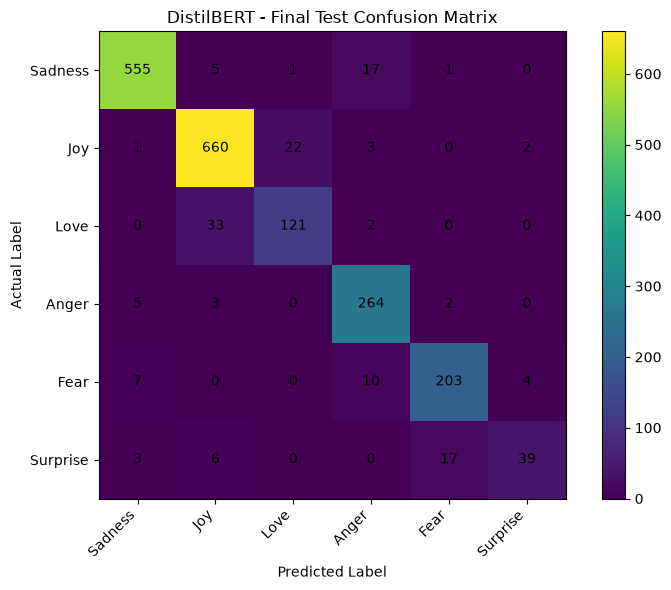

In [34]:
test_conf_matrix = confusion_matrix(
    all_labels,
    all_predictions,
)

fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(test_conf_matrix)

ax.set_title("DistilBERT - Final Test Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right",
)

ax.set_yticklabels(class_names)

for i in range(test_conf_matrix.shape[0]):
    for j in range(test_conf_matrix.shape[1]):
        ax.text(
            j,
            i,
            test_conf_matrix[i, j],
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax)

plt.tight_layout()
plt.show()

In [35]:
test_confusion_df = pd.DataFrame(
    test_conf_matrix,
    index=[f"Actual {name}" for name in class_names],
    columns=[f"Predicted {name}" for name in class_names],
)

display(test_confusion_df)

,Predicted Sadness,Predicted Joy,Predicted Love,Predicted Anger,Predicted Fear,Predicted Surprise
Actual Sadness,555,5,1,17,1,0
Actual Joy,1,660,22,3,0,2
Actual Love,0,33,121,2,0,0
Actual Anger,5,3,0,264,2,0
Actual Fear,7,0,0,10,203,4
Actual Surprise,3,6,0,0,17,39


### Final Test Confusion Matrix Observations

The final test confusion matrix shows that the selected DistilBERT model performs strongly on Sadness, Joy, Anger, and Fear, while the minority classes Love and Surprise remain more difficult.

The largest confusion occurs between Love and Joy, with 33 Love examples predicted as Joy and 22 Joy examples predicted as Love.

Surprise is most frequently confused with Fear, with 17 Surprise examples predicted as Fear. This contributes directly to the lower Surprise recall observed in the final classification report.

Some Sadness examples are also classified as Anger, and a smaller number of Fear examples are classified as Anger or Sadness.

These patterns suggest that emotionally related classes with overlapping contextual language remain difficult to separate perfectly, even when using transformer-based contextual representations.

The final results therefore demonstrate strong overall generalisation while also identifying minority-class performance as an important limitation and area for future improvement.